In [1]:
import torch

In [4]:
x=torch.rand(3,2,4)
w=torch.rand(4,8)

In [32]:
t=torch.rand(3,2,8)
t

tensor([[[0.2319, 0.9843, 0.7240, 0.6380, 0.3498, 0.5038, 0.8714, 0.0211],
         [0.7774, 0.4285, 0.2344, 0.5601, 0.7008, 0.8136, 0.1616, 0.2470]],

        [[0.4432, 0.7192, 0.5525, 0.7388, 0.2183, 0.1835, 0.8580, 0.9401],
         [0.2432, 0.0679, 0.0559, 0.0093, 0.4443, 0.3584, 0.4905, 0.3355]],

        [[0.1387, 0.0694, 0.8483, 0.1184, 0.3602, 0.1467, 0.3237, 0.9384],
         [0.4018, 0.5355, 0.1628, 0.1300, 0.7805, 0.7626, 0.2054, 0.5798]]])

In [29]:
((x@w).topk(2,-1).indices==0).any(-1)

tensor([[ True, False],
        [False,  True],
        [False,  True]])

In [2]:
import torch.nn as nn
import torch.nn.functional as F

In [5]:
nn.Conv2d(18,18,3,groups=1).weight.shape

torch.Size([18, 18, 3, 3])

In [69]:
i=4
b=5

In [71]:
F.conv2d(torch.rand(1,b*i,10,10),torch.rand(b*i,1,3,3),groups=b*i).shape

torch.Size([1, 20, 8, 8])

In [33]:
t[((x@w).topk(2,-1).indices==0).any(-1)]

tensor([[0.2319, 0.9843, 0.7240, 0.6380, 0.3498, 0.5038, 0.8714, 0.0211],
        [0.2432, 0.0679, 0.0559, 0.0093, 0.4443, 0.3584, 0.4905, 0.3355],
        [0.4018, 0.5355, 0.1628, 0.1300, 0.7805, 0.7626, 0.2054, 0.5798]])

In [1]:
import cv2 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image_path = '/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg'

In [3]:
img = np.array(Image.open(image_path).convert('RGB'))

In [4]:
r,g,b=img.transpose(2,0,1)

In [5]:
from scipy.signal import wiener,medfilt2d

In [6]:
def apply_gamma_correction(image, gamma=1.0):
    image_normalized = image / 255.0
    gamma_corrected = np.power(image_normalized, gamma)
    gamma_corrected = np.uint8(gamma_corrected * 255)

    return gamma_corrected

In [7]:
import sys
sys.path.append('/home/duypham/NCKH/Retinal-vessels-segmentation/')
from utils import *


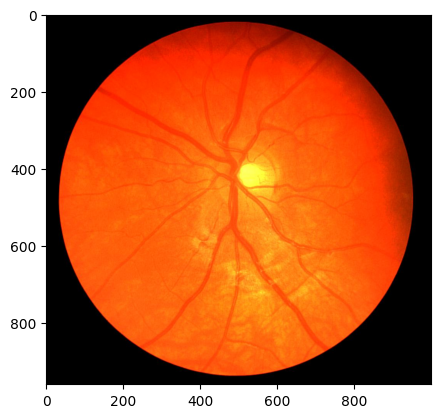

In [8]:
plt.imshow(img)

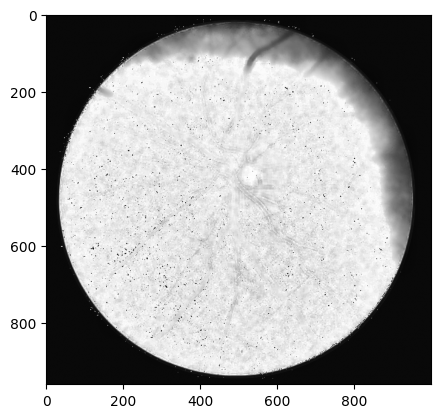

In [68]:
new_r=cv2.createCLAHE(8,(12,12)).apply(wiener(apply_gamma_correction(r,2).astype(np.uint8).astype(np.float32),12).astype(np.uint8)-cv2.resize(HH,(999,960)).astype(np.uint8))
new_g=cv2.createCLAHE(8,(12,12)).apply(g.astype(np.uint8))
new_b=wiener(cv2.createCLAHE(6,(12,12)).apply(b).astype(np.float32),12)
new_img = np.array([new_r,new_g,new_b]).transpose(1,2,0).astype(np.uint8)

plt.imshow(new_r,cmap='gray')

In [26]:
from utils import *

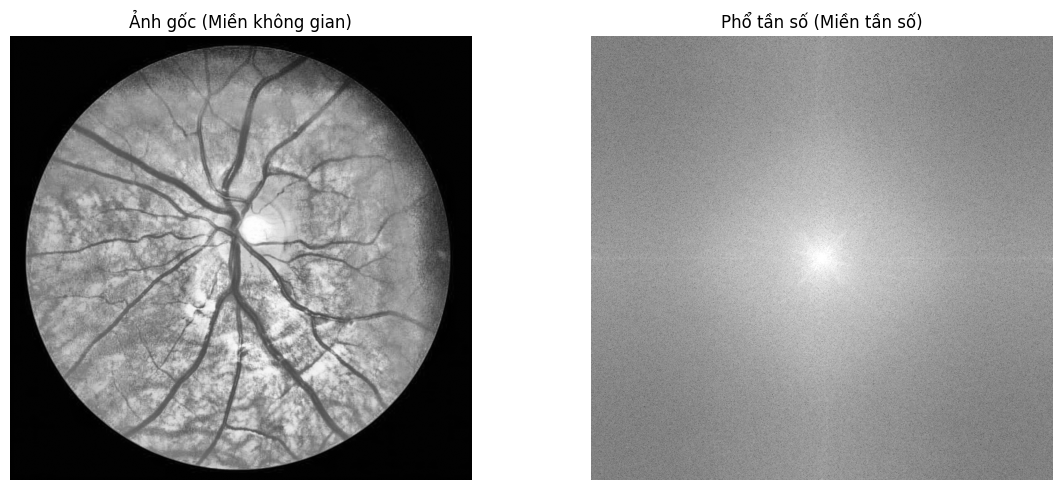

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh dưới dạng grayscale
img = cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/mask/Image_11L_1stHO.png', cv2.IMREAD_GRAYSCALE)

# Áp dụng biến đổi Fourier 2D
f = np.fft.fft2(preprocessing_img(image_path))
fshift = np.fft.fftshift(f)  # Dịch tâm: đưa tần số thấp về giữa

# Tính biên độ phổ (magnitude spectrum)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)  # +1 tránh log(0)

# Hiển thị ảnh gốc và phổ tần số
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Ảnh gốc (Miền không gian)')
plt.imshow(preprocessing_img(image_path), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Phổ tần số (Miền tần số)')
plt.imshow(magnitude_spectrum.clip(0,255).astype(np.uint8), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
[0,0,0,1,2,0]

In [61]:
HH.max()

np.float64(20.000000000000004)

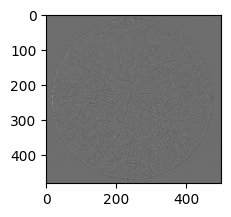

In [83]:
plt.subplot(2, 2, i+1)
plt.imshow(LH+HL+HH, cmap='gray')
# plt.title(titles[i])
# plt.axis('off'

In [72]:
LL

array([[10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       ...,
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.]], shape=(480, 500))

In [76]:
pywt.wavelist()

['bior1.1',
 'bior1.3',
 'bior1.5',
 'bior2.2',
 'bior2.4',
 'bior2.6',
 'bior2.8',
 'bior3.1',
 'bior3.3',
 'bior3.5',
 'bior3.7',
 'bior3.9',
 'bior4.4',
 'bior5.5',
 'bior6.8',
 'cgau1',
 'cgau2',
 'cgau3',
 'cgau4',
 'cgau5',
 'cgau6',
 'cgau7',
 'cgau8',
 'cmor',
 'coif1',
 'coif2',
 'coif3',
 'coif4',
 'coif5',
 'coif6',
 'coif7',
 'coif8',
 'coif9',
 'coif10',
 'coif11',
 'coif12',
 'coif13',
 'coif14',
 'coif15',
 'coif16',
 'coif17',
 'db1',
 'db2',
 'db3',
 'db4',
 'db5',
 'db6',
 'db7',
 'db8',
 'db9',
 'db10',
 'db11',
 'db12',
 'db13',
 'db14',
 'db15',
 'db16',
 'db17',
 'db18',
 'db19',
 'db20',
 'db21',
 'db22',
 'db23',
 'db24',
 'db25',
 'db26',
 'db27',
 'db28',
 'db29',
 'db30',
 'db31',
 'db32',
 'db33',
 'db34',
 'db35',
 'db36',
 'db37',
 'db38',
 'dmey',
 'fbsp',
 'gaus1',
 'gaus2',
 'gaus3',
 'gaus4',
 'gaus5',
 'gaus6',
 'gaus7',
 'gaus8',
 'haar',
 'mexh',
 'morl',
 'rbio1.1',
 'rbio1.3',
 'rbio1.5',
 'rbio2.2',
 'rbio2.4',
 'rbio2.6',
 'rbio2.8',
 'rbio3.1',

In [119]:
x=torch.rand(4,3,5,6)
x

tensor([[[[0.9392, 0.7491, 0.2712, 0.6833, 0.7291, 0.2067],
          [0.7693, 0.0966, 0.3227, 0.0021, 0.3506, 0.2411],
          [0.7992, 0.8740, 0.4478, 0.6082, 0.2259, 0.6503],
          [0.6104, 0.7225, 0.2517, 0.1076, 0.2507, 0.3368],
          [0.9139, 0.3188, 0.0604, 0.6428, 0.4857, 0.0274]],

         [[0.7080, 0.1925, 0.7382, 0.8479, 0.4146, 0.4222],
          [0.3718, 0.1365, 0.3183, 0.4196, 0.2457, 0.6882],
          [0.9362, 0.0139, 0.8940, 0.3929, 0.9559, 0.9601],
          [0.6436, 0.6061, 0.6649, 0.9471, 0.7192, 0.0863],
          [0.9971, 0.7428, 0.3031, 0.0546, 0.7542, 0.7975]],

         [[0.4369, 0.2632, 0.0220, 0.0647, 0.5629, 0.9898],
          [0.0477, 0.0795, 0.6181, 0.0443, 0.7121, 0.3136],
          [0.5532, 0.7507, 0.4144, 0.5446, 0.6894, 0.0749],
          [0.4132, 0.2525, 0.9928, 0.8070, 0.7764, 0.5657],
          [0.7124, 0.1295, 0.3192, 0.7076, 0.5799, 0.2916]]],


        [[[0.3745, 0.3539, 0.8372, 0.4825, 0.1710, 0.7494],
          [0.7513, 0.5689, 0.699

In [ ]:
y=torch.rand(3,5,1,4)

In [111]:
y

tensor([[[[0.3331, 0.9414, 0.5294, 0.5930]]],


        [[[0.3979, 0.0449, 0.3304, 0.7115]]],


        [[[0.5366, 0.8430, 0.1952, 0.9608]]],


        [[[0.1719, 0.6814, 0.0471, 0.6018]]],


        [[[0.1852, 0.5738, 0.2832, 0.9931]]]])

In [ ]:
torch

In [138]:
(y@x.permute(-1,0,1,2)).squeeze()

RuntimeError: The size of tensor a (5) must match the size of tensor b (6) at non-singleton dimension 1

In [133]:
(y@x.permute(2,0,1)).squeeze()[torch.arange(5), torch.arange(5)]

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

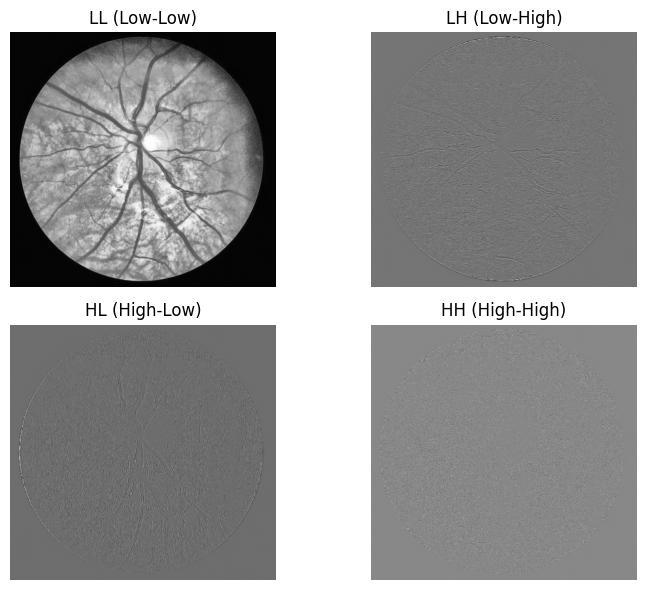

In [82]:
import pywt
img=preprocessing_img(image_path)
coeffs2 = pywt.dwt2(img, 'db2')  # DWT cấp 1
LL, (LH, HL, HH) = coeffs2

# Hiển thị các thành phần tần số
plt.figure(figsize=(8, 6))
titles = ['LL (Low-Low)', 'LH (Low-High)', 'HL (High-Low)', 'HH (High-High)']
for i, comp in enumerate([LL, LH, HL, HH]):
    plt.subplot(2, 2, i+1)
    plt.imshow(comp, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [44]:
HH.min()

np.float64(-33.0)

[[191.51499368 171.37692229 188.30813012 ... 188.30813012 171.37692229
  191.51499368]
 [180.31278384 185.23720078 181.45900449 ... 176.86856836 187.80251964
  181.42557056]
 [198.15383566 178.84715937 189.46793404 ... 189.229988   187.93182195
  187.06885194]
 ...
 [194.99510838 190.69114432 169.21487526 ... 197.50358895 189.82105553
  176.38356016]
 [187.06885194 187.93182195 189.229988   ... 189.46793404 178.84715937
  198.15383566]
 [181.42557056 187.80251964 176.86856836 ... 181.45900449 185.23720078
  180.31278384]]


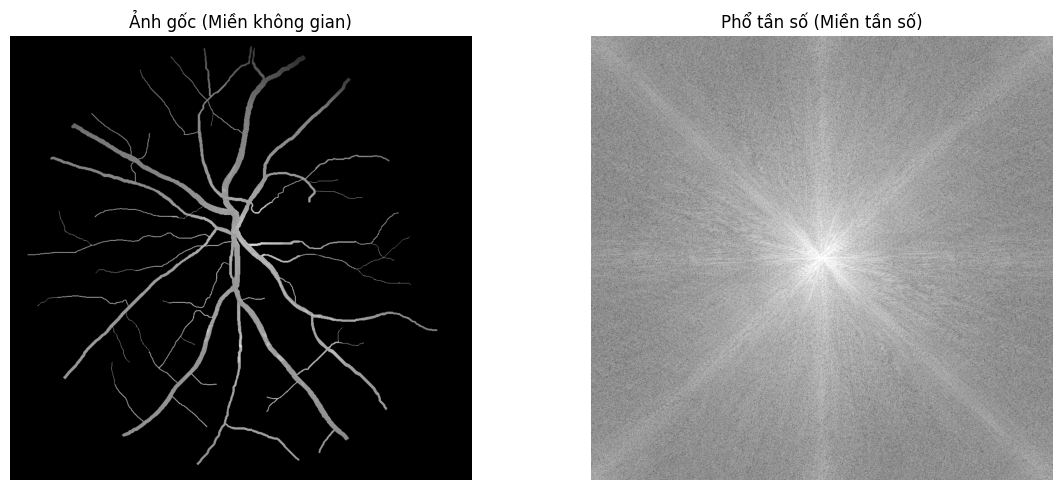

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh dưới dạng grayscale
img_1 = cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/mask/Image_11L_1stHO.png', cv2.IMREAD_GRAYSCALE)
img_2=cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img=(img_1//255)*img_2
# Áp dụng biến đổi Fourier 2D
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)  # Dịch tâm: đưa tần số thấp về giữa

# Tính biên độ phổ (magnitude spectrum)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)  # +1 tránh log(0)
print(magnitude_spectrum)
# Hiển thị ảnh gốc và phổ tần số
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Ảnh gốc (Miền không gian)')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Phổ tần số (Miền tần số)')
plt.imshow(magnitude_spectrum.clip(0,255).astype(np.uint8), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


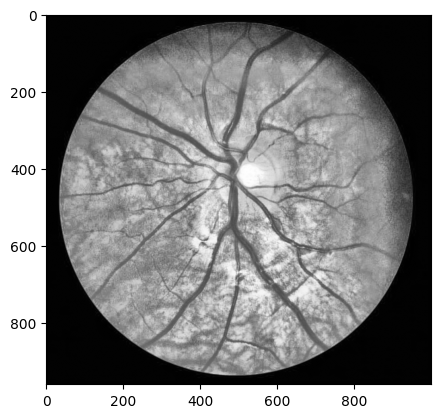

In [10]:
new_r=wiener(apply_gamma_correction(r,2).astype(np.uint8).astype(np.float32),12)
new_g=cv2.createCLAHE(8,(12,12)).apply(g.astype(np.uint8))
new_b=wiener(cv2.createCLAHE(6,(12,12)).apply(b).astype(np.float32),12)
new_img = np.array([new_r,new_g,new_b]).transpose(1,2,0).astype(np.uint8)

plt.imshow(convert_gray(new_img).clip(0,255).astype(np.uint8),cmap='gray')

In [12]:
import pywt
def gamma_correction(image, gamma=1.5):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)
def unsharp_mask(image, ksize=(3,3), sigma=1.0, amount=1.0):
    blur = cv2.GaussianBlur(image, ksize, sigma)
    mask = cv2.subtract(image, blur)
    return cv2.addWeighted(image, 1.0, mask, amount, 0)
def single_scale_retinex(img, sigma):
    blur = cv2.GaussianBlur(img, (0,0), sigma)
    img = np.log1p(img.astype('float64'))
    blur = np.log1p(blur.astype('float64'))
    return np.uint8(np.clip((img - blur) * 255.0, 0, 255))
def homomorphic_filter(img, cutoff=30):
    img_log = np.log1p(img.astype('float32'))
    M, N, _ = img.shape
    # tạo filter Butterworth
    P, Q = 2*M, 2*N
    u = np.arange(P) - P//2
    v = np.arange(Q) - Q//2
    U, V = np.meshgrid(u, v, sparse=False, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = 1 - np.exp(-(D**2)/(2*(cutoff**2)))
    result = np.zeros_like(img_log)
    for c in range(3):
        F = np.fft.fft2(img_log[:,:,c], (P,Q))
        G = H * F
        g = np.fft.ifft2(G)
        g = np.real(g[:M, :N])
        result[:,:,c] = np.expm1(g)
    return np.uint8(np.clip(result, 0, 255))
def wavelet_enhance(img, wavelet='haar', level=1, scale=1.5):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level, axes=(0,1))
    cA, detail_coeffs = coeffs[0], coeffs[1:]
    # tăng hệ số chi tiết
    new_details = []
    for (cH, cV, cD) in detail_coeffs:
        new_details.append((cH*scale, cV*scale, cD*scale))
    new_coeffs = [cA] + new_details
    rec = pywt.waverec2(new_coeffs, wavelet=wavelet, axes=(0,1))
    return np.uint8(np.clip(rec, 0, 255))
def gray_world(image):
    avgB = np.mean(image[:,:,0])
    avgG = np.mean(image[:,:,1])
    avgR = np.mean(image[:,:,2])
    avg = (avgB+avgG+avgR)/3
    scale = [avg/avgB, avg/avgG, avg/avgR]
    result = np.zeros_like(image)
    for i in range(3):
        result[:,:,i] = np.clip(image[:,:,i]*scale[i], 0, 255)
    return np.uint8(result)


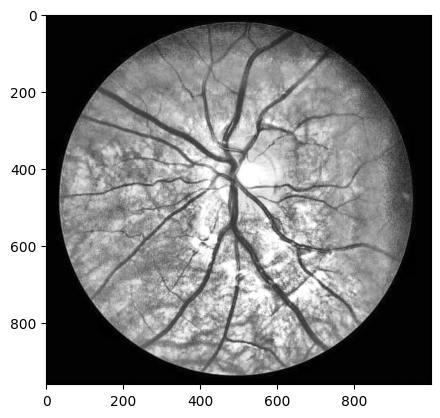

In [13]:
plt.imshow(convert_gray(gray_world(new_img)),cmap='gray')

In [14]:
wavelet_enhance(new_img,level=2, scale=1.3).shape

(960, 1000, 3)

In [15]:
img.shape

(960, 999)

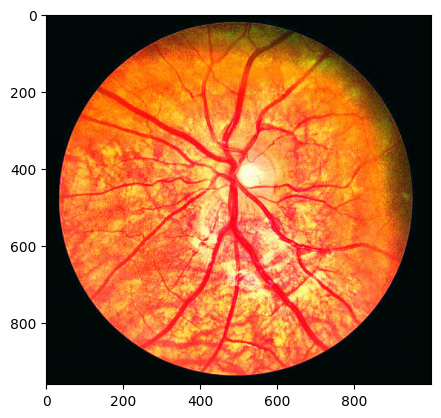

In [16]:
plt.imshow(wavelet_enhance(new_img,level=2, scale=1.3))

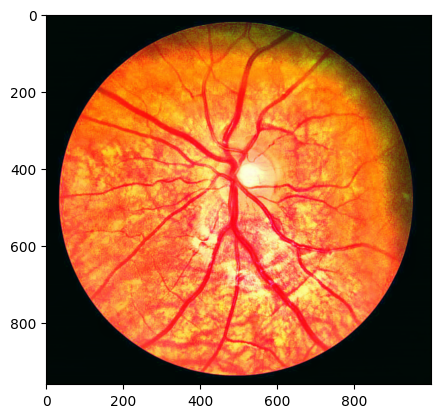

In [17]:
plt.imshow(homomorphic_filter(new_img,80))

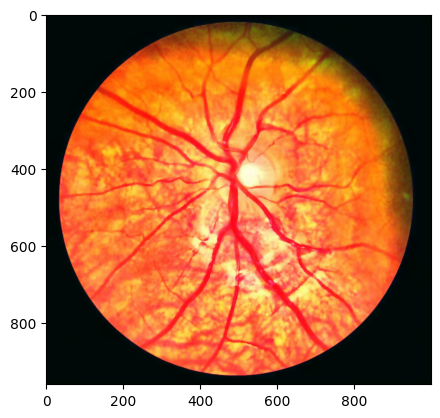

In [18]:
plt.imshow( cv2.bilateralFilter(new_img, d=9, sigmaColor=75, sigmaSpace=75))

In [19]:
unsharp_mask(new_img,amount=1.2).shape

(960, 999, 3)

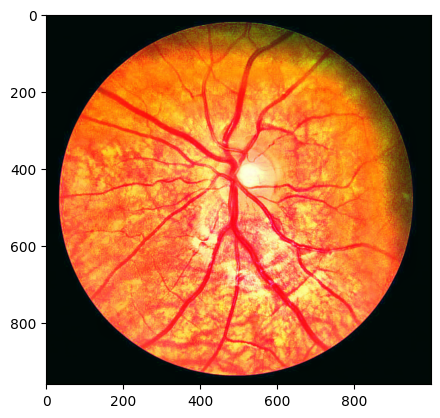

In [20]:
plt.imshow(unsharp_mask(new_img,amount=1.2))

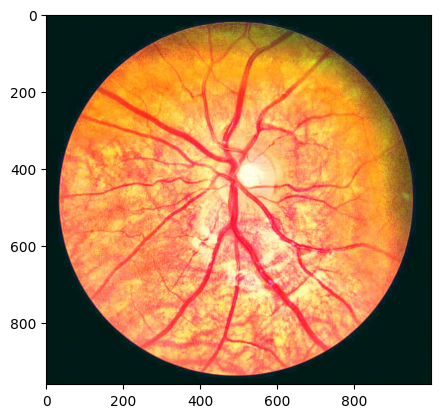

In [21]:
plt.imshow(gamma_correction(new_img,1.5))